### RFM 분석 실습
- Recency: 얼마나 최근에 구매했는가
- Frequency: 얼마나 자주 구매했는가
- Monetary: 얼마나 많은 금액을 지출했는가

### 고객 분석
`customer_shopping_data.csv`
> voice_no: 송장 번호. 명사 같은. 각 작업에 고유하게 할당된 문자 'I'와 6자리 정수의 조합  
customer_id: 고객번호. 명사 같은. 각 작업에 고유하게 할당된 문자 'C'와 6자리 정수의 조합  
gender: 고객 성별의 문자열 변수  
age: 고객 연령의 양의 정수 변수  
category: 구매한 상품 카테고리의 문자열 변수  
quantity: 거래당 각 제품(항목)의 수량  
price: 단가. 숫자. 단위당 제품 가격은 터키 리라(TL)  
payment_method: 거래에 사용된 결제 방법(현금, 신용 카드 또는 직불 카드)의 문자열 변수  
invoice_date: 송장 날짜. 거래가 발생한 날  
shopping_mall: 거래가 이루어진 쇼핑몰 이름의 문자열 변수  

In [1]:
import pandas as pd

cs_df = pd.read_csv('./datasets/customer_shopping_data.csv')
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


In [2]:
cs_df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [3]:
cs_df.duplicated().sum()

0

In [4]:
cs_df.customer_id.value_counts()

customer_id
C241288    1
C116138    1
C382765    1
C285074    1
C405356    1
          ..
C220083    1
C286933    1
C301304    1
C214184    1
C273973    1
Name: count, Length: 99457, dtype: int64

In [6]:
cs_df.customer_id.value_counts().max()

1

In [7]:
cs_df.invoice_date = pd.to_datetime(cs_df.invoice_date, dayfirst=True)
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park


In [8]:
cs_df.sort_values(by='invoice_date', ascending=False)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
386,I289611,C222906,Female,45,Clothing,3,900.24,Debit Card,2023-03-08,Cevahir AVM
20031,I271683,C180068,Male,55,Shoes,1,600.17,Credit Card,2023-03-08,Emaar Square Mall
65073,I312534,C235553,Female,68,Food & Beverage,5,26.15,Credit Card,2023-03-08,Emaar Square Mall
93825,I345170,C108141,Female,20,Food & Beverage,1,5.23,Credit Card,2023-03-08,Kanyon
76606,I254758,C178144,Female,51,Cosmetics,5,203.30,Cash,2023-03-08,Metropol AVM
...,...,...,...,...,...,...,...,...,...,...
65492,I224830,C254068,Female,30,Food & Beverage,3,15.69,Cash,2021-01-01,Metrocity
34180,I211131,C280473,Male,51,Cosmetics,2,81.32,Cash,2021-01-01,Istinye Park
36199,I192911,C642829,Female,66,Food & Beverage,5,26.15,Credit Card,2021-01-01,Metrocity
79607,I474975,C193810,Female,20,Clothing,2,600.16,Credit Card,2021-01-01,Metropol AVM


In [10]:
target = pd.to_datetime('2023-03-09')
cs_df['Recency'] = (target - cs_df.invoice_date).dt.days
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Recency
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,216
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,452
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,485
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,662
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,501
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,169
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul,533
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,711
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park,723


In [11]:
cs_df.drop('invoice_date', axis=1, inplace=True)
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,Recency
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,216
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,452
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,485
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,662
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,501
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,169
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,533
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,711
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,723


In [17]:
# 만약 한 명의 고객이 여러번 주문한 데이터가 아니라면(중복이 없다면),
# 구매한 수량을 Frequency로 설정한다.
cs_df['Frequency'] = cs_df[['quantity']]
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,Recency,Frequency
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,216,5
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,452,3
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,485,1
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,662,5
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,501,4
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,169,5
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,533,2
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,711,2
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,723,4


In [18]:
cs_df['Monetary'] = cs_df['quantity'] * cs_df['price']
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,Recency,Frequency,Monetary
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,216,5,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,452,3,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,485,1,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,662,5,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,501,4,242.40
...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,169,5,293.25
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,533,2,20.92
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,711,2,20.92
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,723,4,16800.00


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
rfm_scaler = scaler.fit_transform(cs_df[['Recency', 'Frequency', 'Monetary']])
rfm_scaler_df = pd.DataFrame(rfm_scaler, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaler_df

,Recency,Frequency,Monetary
0,0.270101,1.00,0.285648
1,0.566583,0.50,0.205614
2,0.608040,0.00,0.011235
3,0.830402,1.00,0.571505
4,0.628141,0.75,0.009037
...,...,...,...
99452,0.211055,1.00,0.010974
99453,0.668342,0.25,0.000598
99454,0.891960,0.25,0.000598
99455,0.907035,0.75,0.639928


In [20]:
rfm_scaler_df['Recency'] = 1 - rfm_scaler_df['Recency']
rfm_scaler_df

,Recency,Frequency,Monetary
0,0.729899,1.00,0.285648
1,0.433417,0.50,0.205614
2,0.391960,0.00,0.011235
3,0.169598,1.00,0.571505
4,0.371859,0.75,0.009037
...,...,...,...
99452,0.788945,1.00,0.010974
99453,0.331658,0.25,0.000598
99454,0.108040,0.25,0.000598
99455,0.092965,0.75,0.639928


In [21]:
cs_df['total_score'] = rfm_scaler_df['Recency'] + rfm_scaler_df['Frequency'] + rfm_scaler_df['Monetary']
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,Recency,Frequency,Monetary,total_score
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,216,5,7502.00,2.015548
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,452,3,5401.53,1.139031
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,485,1,300.08,0.403194
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,662,5,15004.25,1.741103
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,501,4,242.40,1.130896
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,169,5,293.25,1.799919
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,533,2,20.92,0.582256
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,711,2,20.92,0.358638
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,723,4,16800.00,1.482893


In [22]:
import numpy as np

l1, l2, l3, l4 = np.percentile(cs_df['total_score'], [20, 40, 65, 85])
print(l1, l2, l3, l4)

0.6209409560600792 0.9337272654369081 1.293727390793303 1.6795453046885398


In [23]:
def get_level(x) :
  if x <= l1 :
    return 5
  elif x > l1 and x <= l2 :
    return 4
  elif x > l2 and x <= l3 :
    return 3
  elif x > l3 and x <= l4 :
    return 2
  elif x > l4 :
    return 1

In [24]:
cs_df['level'] = cs_df['total_score'].apply(get_level)

In [25]:
cs_df.drop(labels=['Recency', 'Frequency', 'Monetary'], axis=1, inplace=True)
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,total_score,level
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,2.015548,1
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,1.139031,3
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,0.403194,5
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,1.741103,1
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,1.130896,3
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,1.799919,1
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,0.582256,5
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,0.358638,5
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,1.482893,2


In [26]:
cs_df['level'] = cs_df['level'].replace([1, 2, 3, 4, 5], ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP'])
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,total_score,level
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,Kanyon,2.015548,Bronze
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,Forum Istanbul,1.139031,Gold
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,0.403194,VIP
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,Metropol AVM,1.741103,Bronze
4,I337046,C189076,Female,53,Books,4,60.60,Cash,Kanyon,1.130896,Gold
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,Kanyon,1.799919,Bronze
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,Forum Istanbul,0.582256,VIP
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,Metrocity,0.358638,VIP
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,Istinye Park,1.482893,Silver


Level Count:
level
Gold       24856
Diamond    19897
VIP        19895
Silver     19892
Bronze     14917
Name: count, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10700\2531303122.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='level', data=cs_df, palette='muted', order=order)


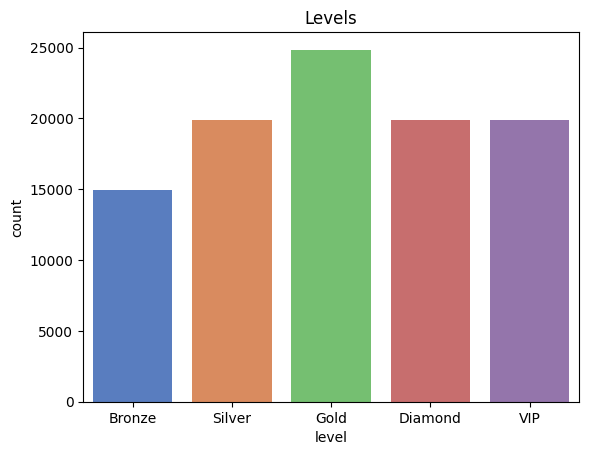

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP']

print('Level Count:')
print(cs_df['level'].value_counts())

sns.countplot(x='level', data=cs_df, palette='muted', order=order)
plt.title('Levels')
plt.show()

In [28]:
import math
cs_df.age = cs_df.age.apply(lambda x: math.floor(x / 10) * 10)
cs_df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,shopping_mall,total_score,level
0,I138884,C241288,Female,20,Clothing,5,1500.40,Credit Card,Kanyon,2.015548,Bronze
1,I317333,C111565,Male,20,Shoes,3,1800.51,Debit Card,Forum Istanbul,1.139031,Gold
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,Metrocity,0.403194,VIP
3,I173702,C988172,Female,60,Shoes,5,3000.85,Credit Card,Metropol AVM,1.741103,Bronze
4,I337046,C189076,Female,50,Books,4,60.60,Cash,Kanyon,1.130896,Gold
...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,40,Souvenir,5,58.65,Credit Card,Kanyon,1.799919,Bronze
99453,I325143,C569580,Male,20,Food & Beverage,2,10.46,Cash,Forum Istanbul,0.582256,VIP
99454,I824010,C103292,Male,60,Food & Beverage,2,10.46,Debit Card,Metrocity,0.358638,VIP
99455,I702964,C800631,Male,50,Technology,4,4200.00,Cash,Istinye Park,1.482893,Silver


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10700\3065876268.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i], x=col, data=cs_df, palette='muted')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10700\3065876268.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i], x=col, data=cs_df, palette='muted')


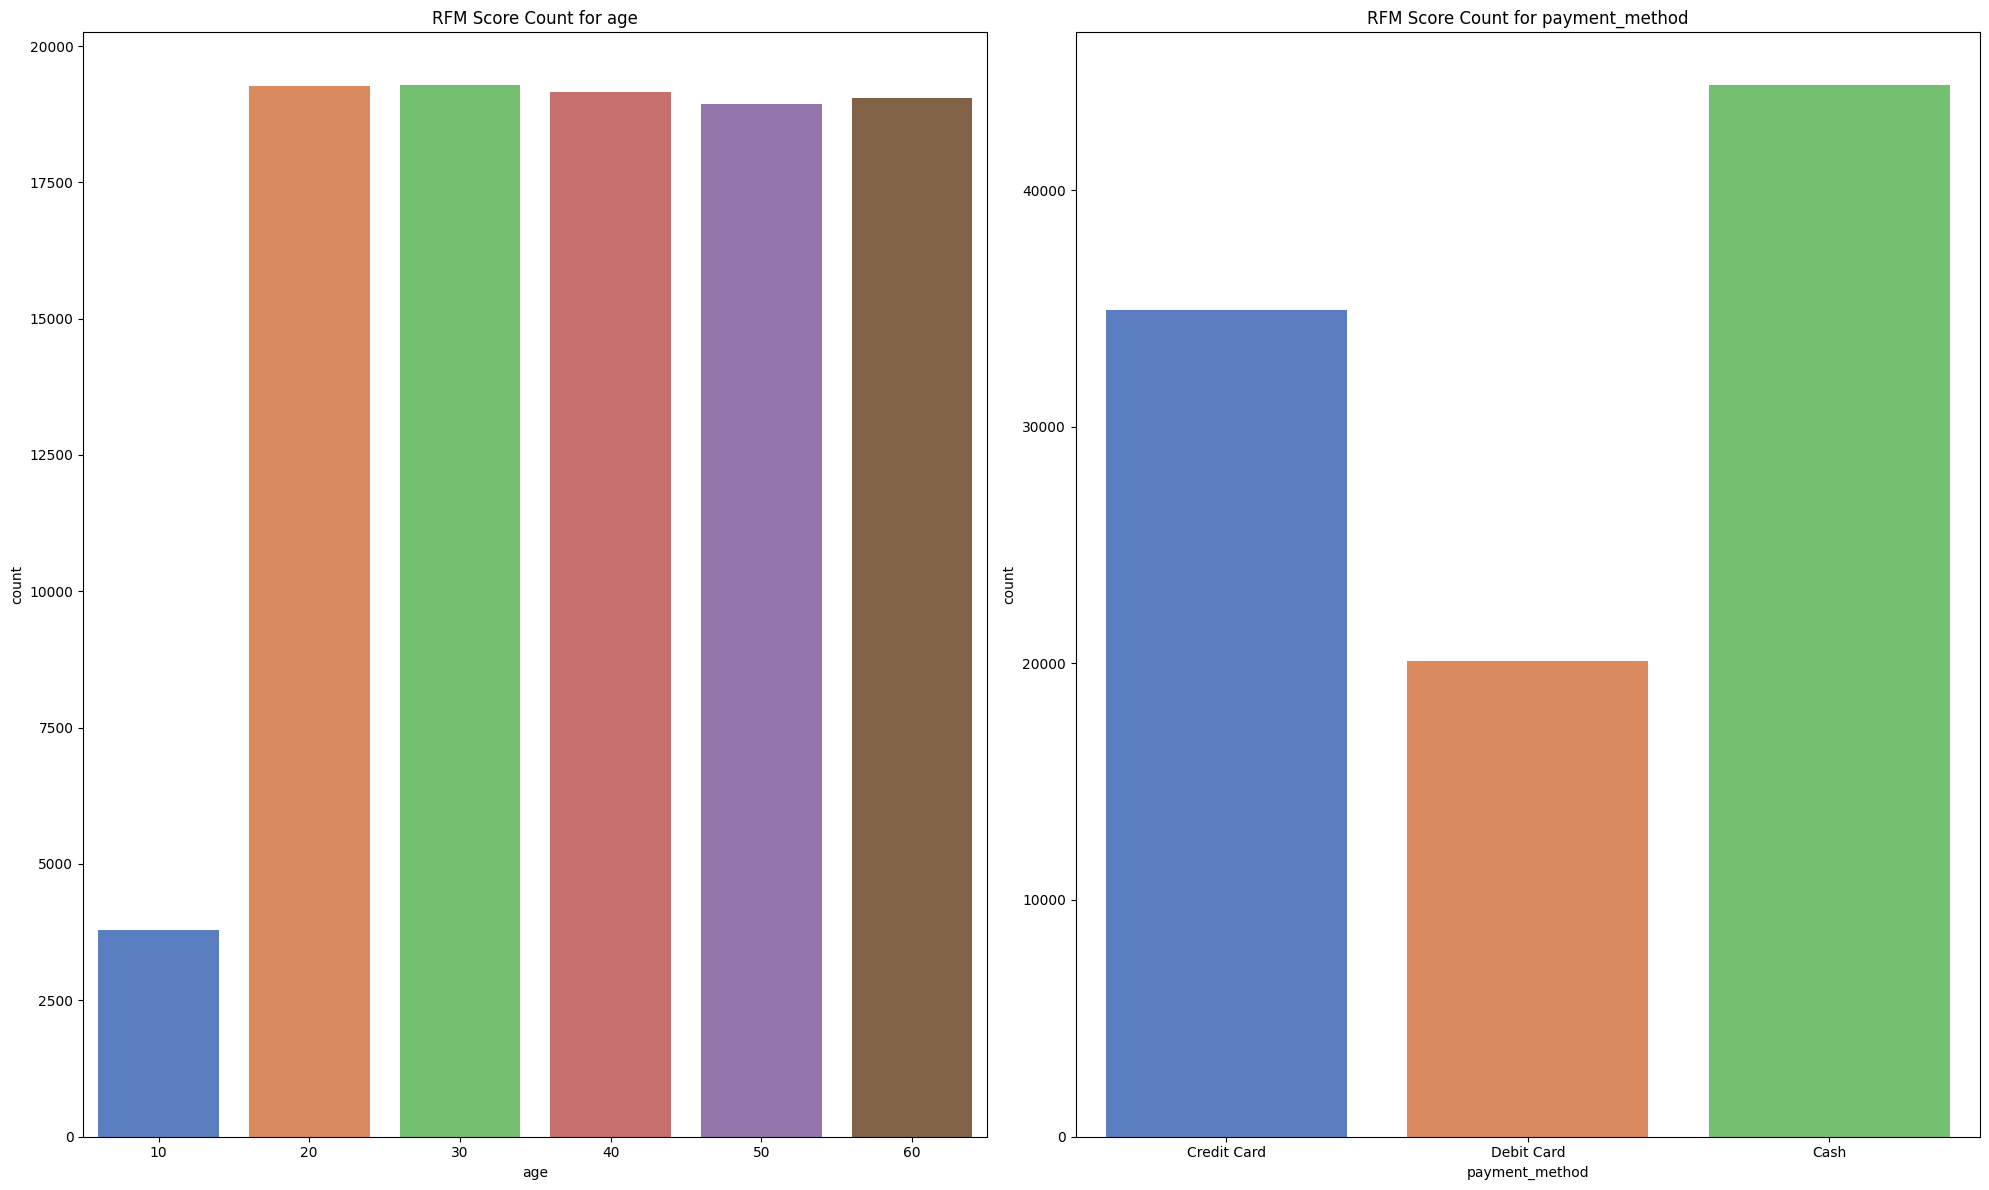

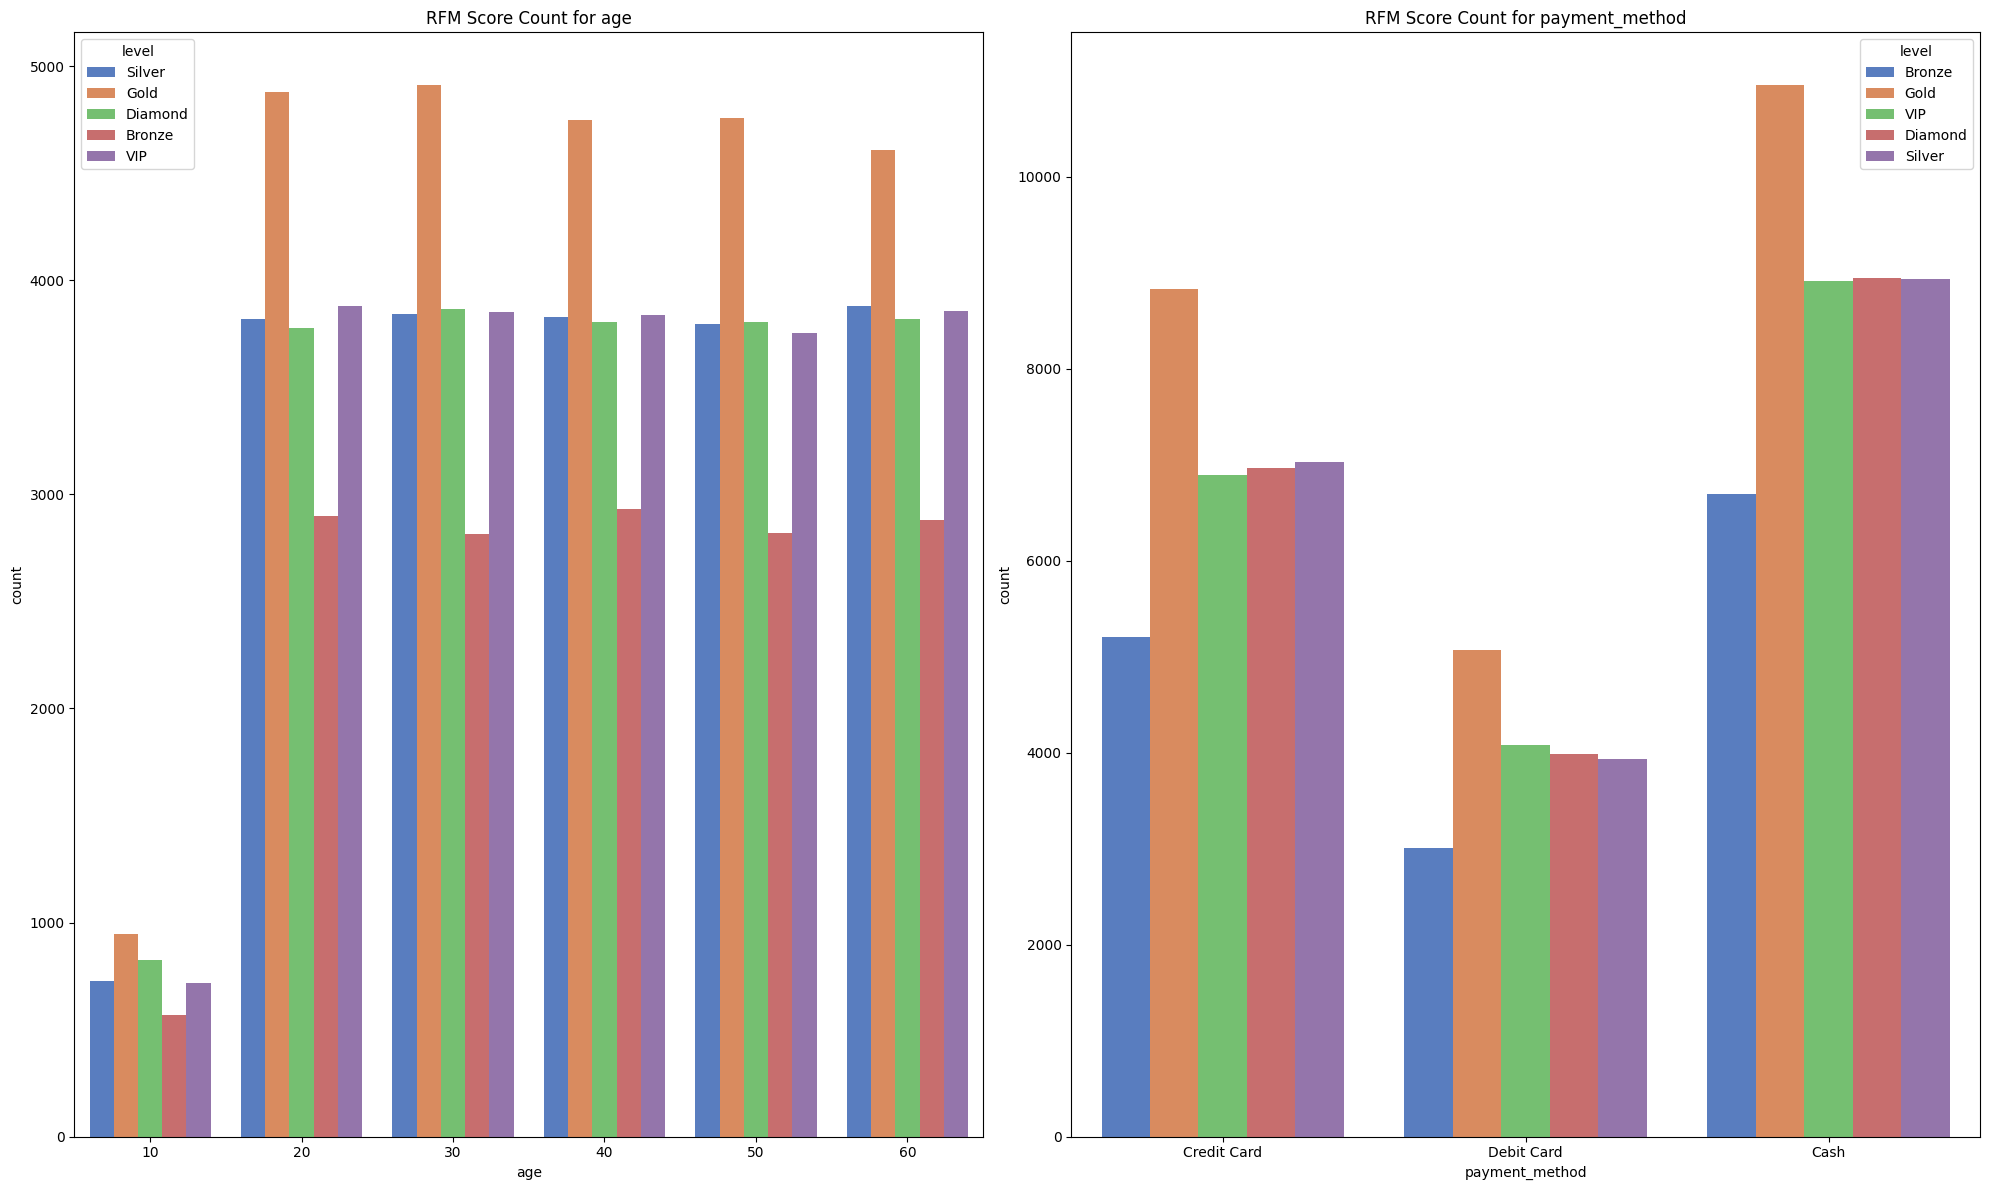

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for i, col in enumerate(['age', 'payment_method']):
    sns.countplot(ax=axes[i], x=col, data=cs_df, palette='muted')
    axes[i].set_title(f'RFM Score Count for {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for i, col in enumerate(['age', 'payment_method']):
    sns.countplot(ax=axes[i], x=col, hue='level', data=cs_df, palette='muted')
    axes[i].set_title(f'RFM Score Count for {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10700\2321404784.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes, x='shopping_mall', data=cs_df, palette='muted')


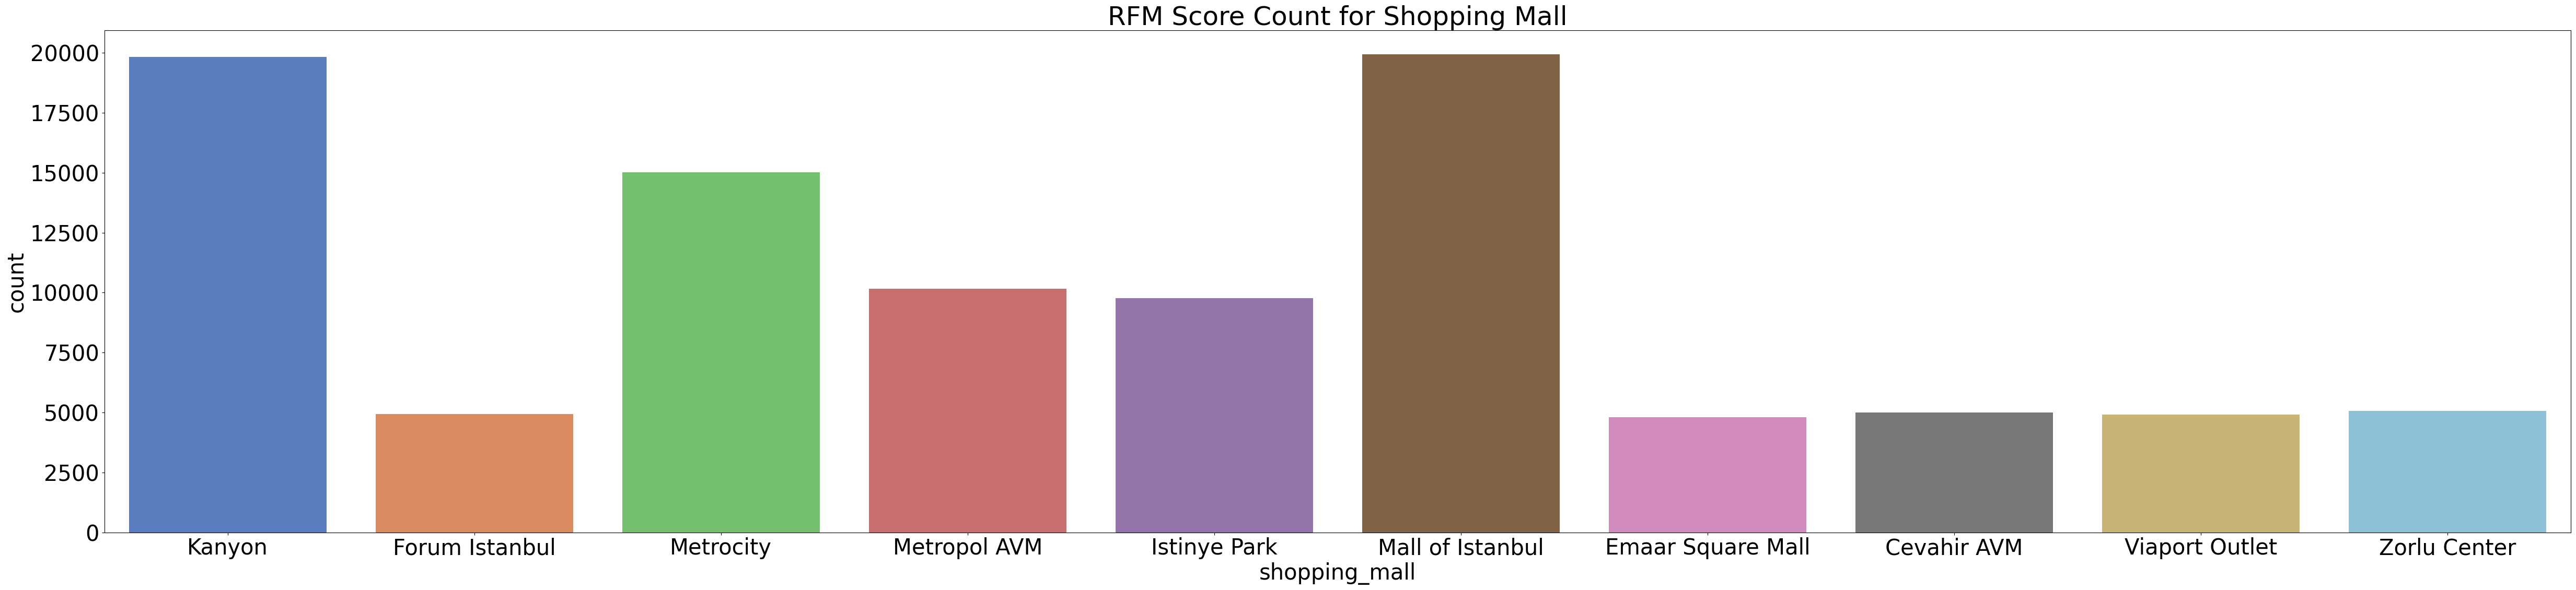

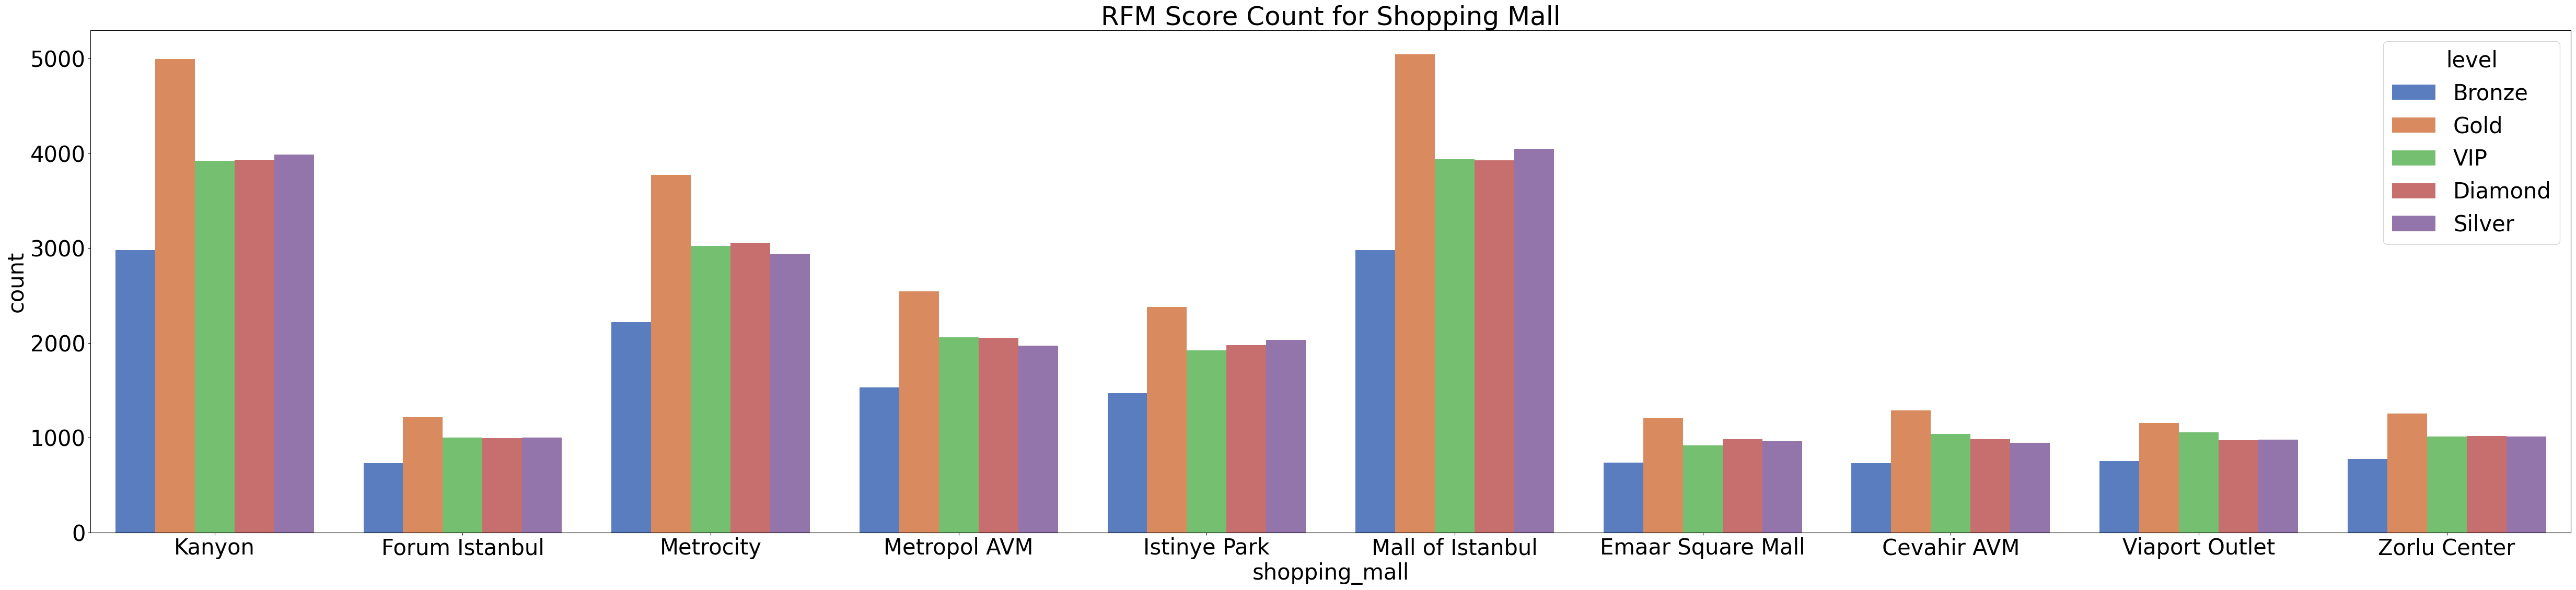

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', size=30)

fig, axes = plt.subplots(1, 1, figsize=(50, 12))

sns.countplot(ax=axes, x='shopping_mall', data=cs_df, palette='muted')
axes.set_title(f'RFM Score Count for Shopping Mall')
axes.set_xlabel('shopping_mall')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(50, 12))

sns.countplot(ax=axes, x='shopping_mall', hue='level', data=cs_df, palette='muted')
axes.set_title(f'RFM Score Count for Shopping Mall')
axes.set_xlabel('shopping_mall')

plt.tight_layout()
plt.show()